# Restaurant POS Sales Analysis


## Objective

Analyze restaurant point-of-sale records to understand revenue patterns, menu performance, server performance, and the characteristics associated with high-value POS records. Each row is one menu-item line; the source has no order or receipt ID, so order-level metrics are not calculated.


## Setup

Reusable data cleaning, feature engineering, and model training code lives in the `src/` folder. The notebook focuses on the analysis workflow and business interpretation.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_cleaning import clean_pos_data, get_data_quality_summary, load_pos_data
from src.feature_engineering import add_high_revenue_target, add_time_features
from src.model import evaluate_revenue_models, get_feature_importance

DATA_PATH = PROJECT_ROOT / "Data" / "steakhouse_pos_simulated_data.csv"


## Data Loading and Preparation


In [2]:
raw_df = load_pos_data(DATA_PATH)

df = clean_pos_data(raw_df)
df = add_time_features(df)
df = add_high_revenue_target(df)

df.head()


,Date,Time,Menu Item,Category,Quantity,Price (per item),Revenue,Payment Method,Order Type,Server ID,Server Name,Hour,Weekday,Month,Month Name,Day of Week,IsWeekend,High Revenue
0,2024-11-23,12:00:00,Truffle Fries,Side,5.0,8,40.0,Cash,Dine-In,102,Jake,12,Saturday,11,November,5,True,False
1,2024-02-22,21:00:00,Chocolate Lava Cake,Dessert,8.0,9,72.0,Cash,Dine-In,101,Sarah,21,Thursday,2,February,3,False,True
2,2024-04-21,14:00:00,Cabernet Sauvignon,Beverage,2.0,16,32.0,Mobile Payment,Delivery,105,Nina,14,Sunday,4,April,6,True,False
3,2024-08-02,14:45:00,Chocolate Lava Cake,Dessert,5.0,9,45.0,Cash,Dine-In,104,Carlos,14,Friday,8,August,4,False,False
4,2024-06-23,15:15:00,Caesar Salad,Appetizer,3.0,10,30.0,Cash,Dine-In,104,Carlos,15,Sunday,6,June,6,True,False


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              5000 non-null   datetime64[ns]
 1   Time              5000 non-null   object        
 2   Menu Item         5000 non-null   object        
 3   Category          5000 non-null   object        
 4   Quantity          5000 non-null   float64       
 5   Price (per item)  5000 non-null   int64         
 6   Revenue           5000 non-null   float64       
 7   Payment Method    5000 non-null   object        
 8   Order Type        5000 non-null   object        
 9   Server ID         5000 non-null   int64         
 10  Server Name       5000 non-null   object        
 11  Hour              5000 non-null   int64         
 12  Weekday           5000 non-null   object        
 13  Month             5000 non-null   int32         
 14  Month Name        5000 n

## Data Quality Checks


In [4]:
get_data_quality_summary(df)


,missing_values,unique_values,data_type
Date,0,366,datetime64[ns]
Time,0,48,object
Menu Item,0,12,object
Category,0,5,object
Quantity,0,36,float64
Price (per item),0,11,int64
Revenue,0,133,float64
Payment Method,0,3,object
Order Type,0,3,object
Server ID,0,5,int64


In [5]:
duplicate_rows = df.duplicated().sum()
duplicate_rows


np.int64(0)

## Key Business Metrics


In [6]:
total_revenue = df["Revenue"].sum()
total_records = len(df)
average_line_revenue = df["Revenue"].mean()
total_units_sold = df["Quantity"].sum()

pd.DataFrame(
    {
        "Metric": [
            "Total Revenue",
            "POS Records",
            "Average Line Revenue",
            "Total Units Sold",
        ],
        "Value": [
            total_revenue,
            total_records,
            average_line_revenue,
            total_units_sold,
        ],
    }
)


,Metric,Value
0,Total Revenue,440324.20000
1,POS Records,5000.00000
2,Average Line Revenue,88.06484
3,Total Units Sold,24067.60000


## Exploratory Data Analysis


In [7]:
category_revenue = (
    df.groupby("Category")
    .agg(
        Revenue=("Revenue", "sum"),
        POS_Records=("Revenue", "size"),
        Quantity=("Quantity", "sum"),
        Average_Line_Revenue=("Revenue", "mean"),
    )
    .sort_values("Revenue", ascending=False)
)

category_revenue["Revenue_Share"] = category_revenue["Revenue"] / total_revenue
category_revenue


,Revenue,POS_Records,Quantity,Average_Line_Revenue,Revenue_Share
Category,,,,,
Entree,272974.9,1658,7969.8,164.641074,0.619941
Beverage,53358.4,796,3821.1,67.033166,0.121180
Side,48710.9,1323,6359.2,36.818519,0.110625
Appetizer,47541.0,829,3946.5,57.347407,0.107968
Dessert,17739.0,394,1971.0,45.022843,0.040286


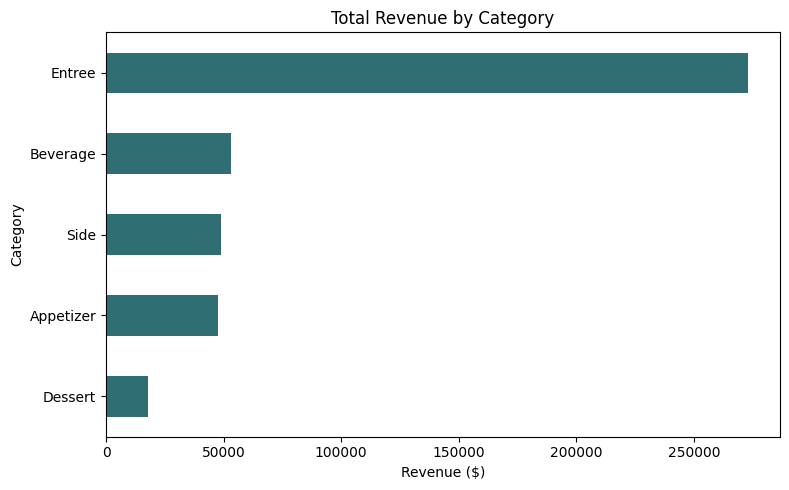

In [8]:
ax = category_revenue.sort_values("Revenue")["Revenue"].plot(
    kind="barh",
    figsize=(8, 5),
    color="#2F6F73",
)
ax.set_title("Total Revenue by Category")
ax.set_xlabel("Revenue ($)")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()


In [9]:
top_items = (
    df.groupby("Menu Item")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        POS_Records=("Revenue", "size"),
        Average_Line_Revenue=("Revenue", "mean"),
    )
    .sort_values("Revenue", ascending=False)
)

top_items["Revenue_Share"] = top_items["Revenue"] / total_revenue
top_items.head(10)


,Revenue,Quantity,POS_Records,Average_Line_Revenue,Revenue_Share
Menu Item,,,,,
New York Strip,82771.6,2178.2,449,184.346548,0.187979
Filet Mignon,82395.6,1961.8,413,199.505085,0.187125
Ribeye Steak,63409.5,1811.7,385,164.700000,0.144006
Bourbon BBQ Burger,44398.2,2018.1,411,108.024818,0.100831
Cabernet Sauvignon,30020.8,1876.3,397,75.619144,0.068179
Shrimp Cocktail,28266.0,2019.0,426,66.352113,0.064194
Old Fashioned,23337.6,1944.8,399,58.490226,0.053001
Caesar Salad,19275.0,1927.5,403,47.828784,0.043775
Chocolate Lava Cake,17739.0,1971.0,394,45.022843,0.040286


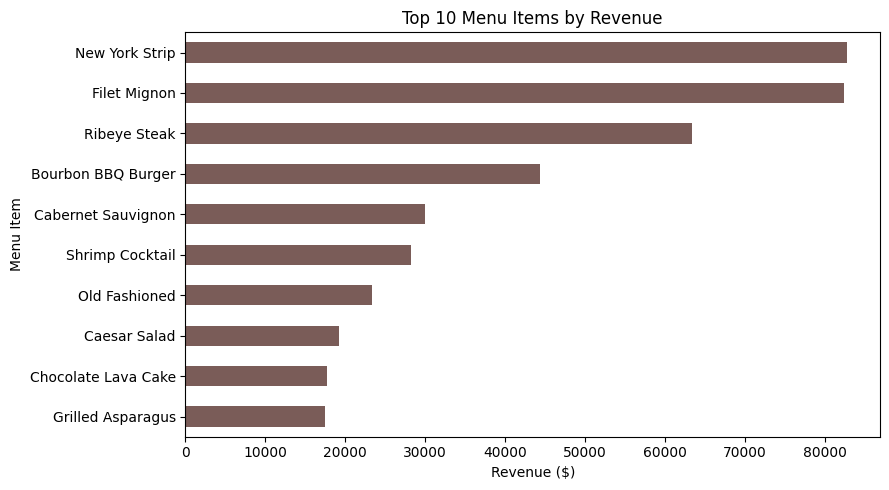

In [10]:
ax = top_items.head(10).sort_values("Revenue")["Revenue"].plot(
    kind="barh",
    figsize=(9, 5),
    color="#7A5C58",
)
ax.set_title("Top 10 Menu Items by Revenue")
ax.set_xlabel("Revenue ($)")
ax.set_ylabel("Menu Item")
plt.tight_layout()
plt.show()


## Time-Based Sales Trends


In [11]:
daily_revenue = df.groupby("Date")["Revenue"].sum().reset_index()
daily_revenue["Weekday"] = daily_revenue["Date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_average_revenue = (
    daily_revenue.groupby("Weekday")["Revenue"]
    .mean()
    .reindex(weekday_order)
    .sort_values(ascending=False)
)

weekday_average_revenue


Weekday
Saturday     1421.846154
Friday       1221.096154
Sunday       1205.057692
Tuesday      1148.769811
Wednesday    1147.107692
Monday       1142.267925
Thursday     1137.569231
Name: Revenue, dtype: float64

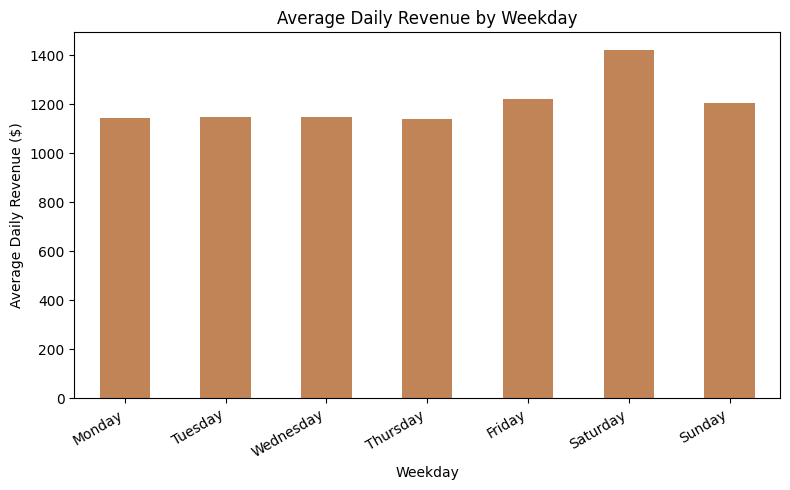

In [12]:
ax = weekday_average_revenue.reindex(weekday_order).plot(
    kind="bar",
    figsize=(8, 5),
    color="#C08457",
)
ax.set_title("Average Daily Revenue by Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Average Daily Revenue ($)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [13]:
hourly_revenue = (
    df.groupby("Hour")
    .agg(
        Revenue=("Revenue", "sum"),
        POS_Records=("Revenue", "size"),
        Average_Line_Revenue=("Revenue", "mean"),
    )
    .sort_values("Revenue", ascending=False)
)

hourly_revenue.head(10)


,Revenue,POS_Records,Average_Line_Revenue
Hour,,,
19,48772.6,435,112.120920
20,48367.8,429,112.745455
21,47722.5,424,112.553066
17,45983.0,427,107.688525
22,45648.8,411,111.067640
18,44716.3,436,102.560321
13,29030.2,439,66.128018
12,28317.0,423,66.943262
15,25866.8,385,67.186494


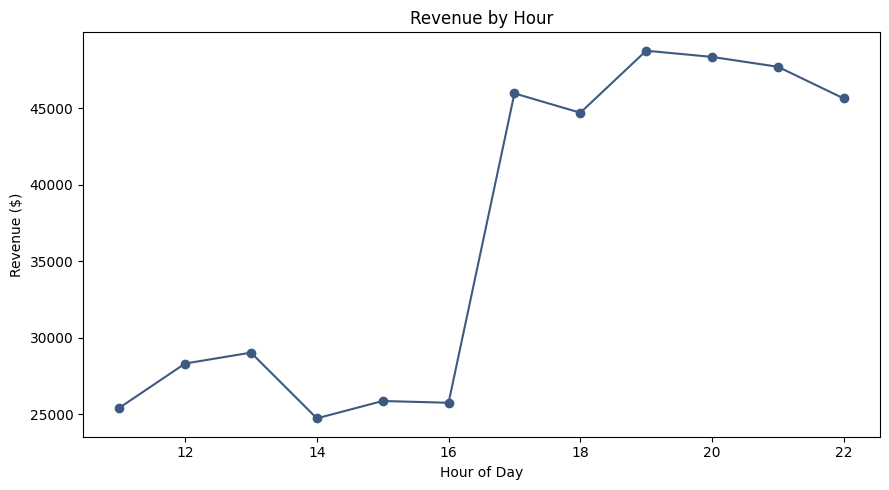

In [14]:
ax = hourly_revenue.sort_index()["Revenue"].plot(
    kind="line",
    marker="o",
    figsize=(9, 5),
    color="#3D5A80",
)
ax.set_title("Revenue by Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Revenue ($)")
plt.tight_layout()
plt.show()


## Server Performance


In [15]:
server_performance = (
    df.groupby("Server Name")
    .agg(
        Revenue=("Revenue", "sum"),
        POS_Records=("Revenue", "size"),
        Quantity=("Quantity", "sum"),
        Average_Line_Revenue=("Revenue", "mean"),
    )
    .sort_values("Revenue", ascending=False)
)

server_performance["Revenue_Share"] = server_performance["Revenue"] / total_revenue
server_performance


,Revenue,POS_Records,Quantity,Average_Line_Revenue,Revenue_Share
Server Name,,,,,
Nina,91506.8,1028,4968.3,89.014397,0.207817
Sarah,89615.0,1047,4914.6,85.592168,0.203520
Jake,89288.2,974,4865.1,91.671663,0.202778
Carlos,86349.1,995,4720.5,86.783015,0.196103
Emily,83565.1,956,4599.1,87.411192,0.189781


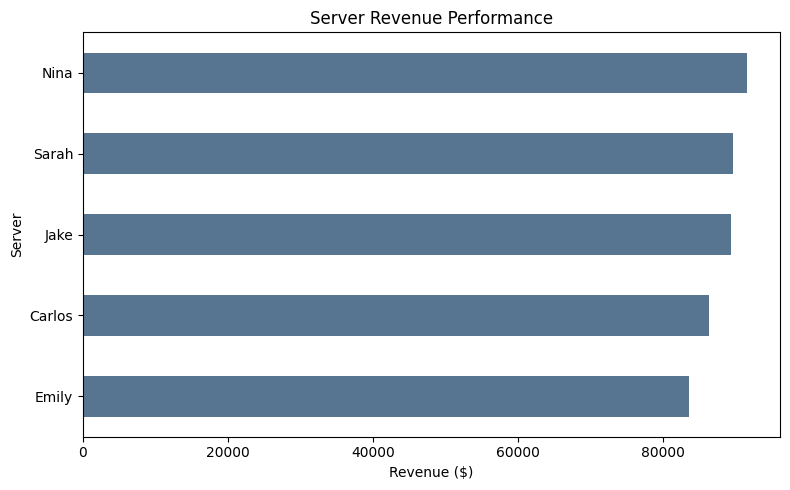

In [16]:
ax = server_performance.sort_values("Revenue")["Revenue"].plot(
    kind="barh",
    figsize=(8, 5),
    color="#577590",
)
ax.set_title("Server Revenue Performance")
ax.set_xlabel("Revenue ($)")
ax.set_ylabel("Server")
plt.tight_layout()
plt.show()


In [17]:
server_category_mix = (
    df.groupby(["Server Name", "Category"])["Quantity"]
    .sum()
    .reset_index()
)

server_category_mix["Percentage"] = (
    server_category_mix["Quantity"]
    / server_category_mix.groupby("Server Name")["Quantity"].transform("sum")
    * 100
)

server_category_mix.round(2)


,Server Name,Category,Quantity,Percentage
0,Carlos,Appetizer,721.5,15.28
1,Carlos,Beverage,823.5,17.45
2,Carlos,Dessert,308.0,6.52
3,Carlos,Entree,1570.3,33.27
4,Carlos,Side,1297.2,27.48
5,Emily,Appetizer,721.0,15.68
6,Emily,Beverage,702.0,15.26
7,Emily,Dessert,452.0,9.83
8,Emily,Entree,1511.9,32.87
9,Emily,Side,1212.2,26.36


## Model Evaluation

This classification experiment identifies characteristics associated with high-value POS records. Because menu item is already known and carries price information, the model is descriptive rather than a forecast of customer spend.


In [18]:
model_evaluation = evaluate_revenue_models(df)
model_evaluation["summary"][["Model", "Accuracy", "F1", "ROC_AUC", "CV_F1_Mean"]].rename(
    columns={"ROC_AUC": "ROC-AUC", "CV_F1_Mean": "CV F1"}
).round(3)


,Model,Accuracy,F1,ROC-AUC,CV F1
2,Random Forest,0.792,0.786,0.889,0.775
1,Logistic Regression,0.773,0.763,0.881,0.768
0,Dummy Baseline,0.501,0.000,0.500,0.000


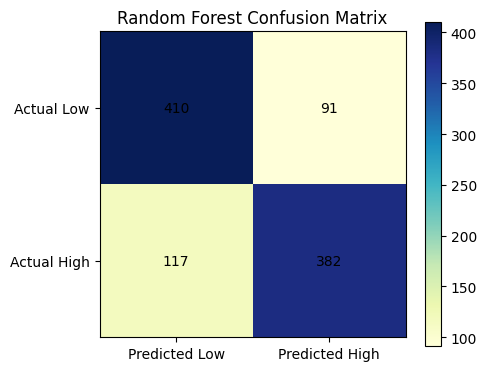

              precision    recall  f1-score   support

       False       0.78      0.82      0.80       501
        True       0.81      0.77      0.79       499

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.79      0.79      0.79      1000



In [19]:
random_forest_results = model_evaluation["models"]["Random Forest"]

confusion = random_forest_results["confusion_matrix"]
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(confusion, cmap="YlGnBu")
for row in range(confusion.shape[0]):
    for column in range(confusion.shape[1]):
        ax.text(column, row, confusion[row, column], ha="center", va="center")
ax.set_xticks([0, 1], labels=["Predicted Low", "Predicted High"])
ax.set_yticks([0, 1], labels=["Actual Low", "Actual High"])
ax.set_title("Random Forest Confusion Matrix")
plt.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

print(random_forest_results["classification_report"])


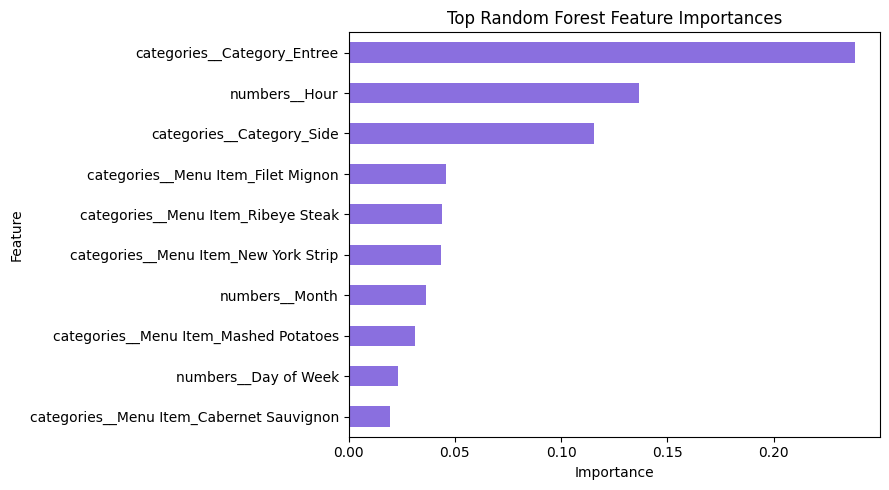

In [20]:
feature_importance = get_feature_importance(random_forest_results["model"])

ax = feature_importance.head(10).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(9, 5),
    legend=False,
    color="#8A6FDF",
)
ax.set_title("Top Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


## Business Recommendations

- Prioritize premium entree promotion, especially steak items that account for the majority of revenue.
- Test dessert upselling strategies and measure whether they increase dessert revenue; the current 4% share does not prove poor performance.
- Staff peak dinner hours carefully, especially between 7 PM and 9 PM.
- Use Saturday demand patterns to guide inventory planning and scheduling.
- Study top-performing server POS record patterns to form testable training hypotheses.
- Use the classifier to describe high-value POS record patterns, not to forecast customer spend or evaluate staff.


## Conclusion

The analysis identifies revenue patterns across menu items, weekdays, hours, and servers. The model comparison adds a classification experiment showing which recorded characteristics are associated with above-median line revenue, without claiming to forecast complete order value.
